In [1]:
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('../../..'))
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  #
import plotly.graph_objects as go

# **Loading .npy files from folders**

In [2]:
param_space_kfender_Iy = np.load('runs_kfender_Iy_retainingwall/' \
'param_space_N200_kfender_10000000000000.0_Iy1500_10000.npy')

params_kfender_kr = np.load('runs_kfender_kr/param_space_N200_kr0_' \
'10000000000000.0_kf100_300000000.npy')

params_kr_Iy = np.load('runs_kr_Iy_retainingwall/param_space_N200_kr0_' \
'10000000000000.0_Iy1500_10000.npy')

# **Relevant plots**

$k_{fender}$ vs $I_y$

In [3]:
# Plots for kfender vs Iy
N = 200
k_fender_min = 0
k_fender_max = 10000000000000

Iy_min = 1500
Iy_max = 10000

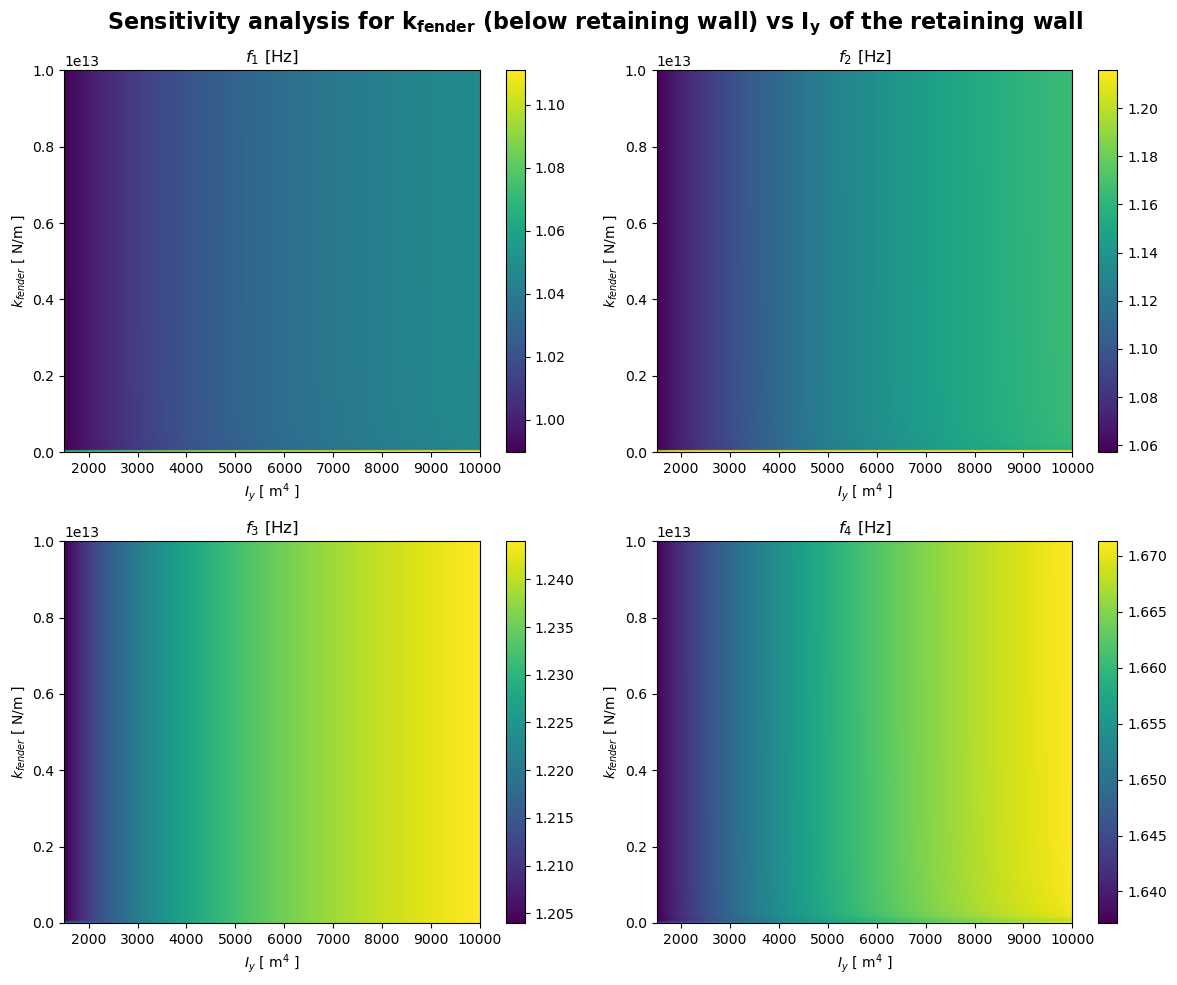

In [4]:
k_fender = np.arange(k_fender_min, k_fender_max, (k_fender_max - k_fender_min) / N)
Iy = np.arange(Iy_min, Iy_max, (Iy_max - Iy_min) / N)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
titles = ['$f_1$ [Hz]', '$f_2$ [Hz]', '$f_3$ [Hz]', '$f_4$ [Hz]']

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        param_space_kfender_Iy[:, :, i],
        extent=(Iy_min, Iy_max, k_fender_min, k_fender_max),
        origin='lower',
        aspect='auto'
    )
    
    ax.set_xlabel('$I_y$ [ m$^4$ ]')
    ax.set_ylabel('$k_{fender}$ [ N/m ]')
    ax.set_title(titles[i])
    
    fig.colorbar(im, ax=ax)

fig.suptitle(
    r'Sensitivity analysis for $\mathbf{k_{fender}}$ (below retaining wall) vs $\mathbf{I_y}$ of the retaining wall',
    fontsize=16,
    y=0.98,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('plots/model2_colorbar_kfender_Iy.jpg', dpi=500)
plt.show()


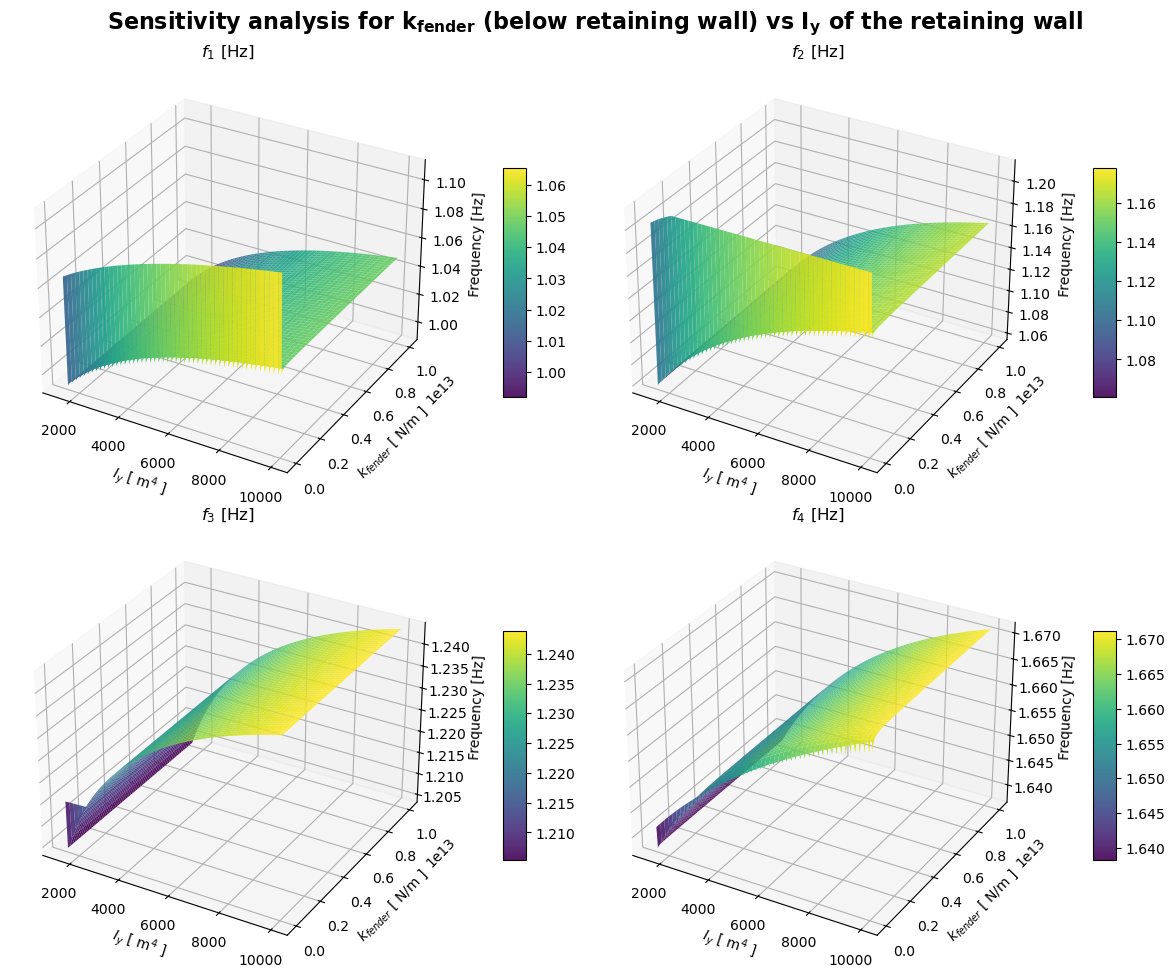

In [5]:

# Create meshgrid for plotting
Iy_grid, kf_grid = np.meshgrid(
    np.linspace(Iy_min, Iy_max, param_space_kfender_Iy.shape[1]),
    np.linspace(k_fender_min, k_fender_max, param_space_kfender_Iy.shape[0])
)

fig = plt.figure(figsize=(12, 10))
titles = ['$f_1$ [Hz]', '$f_2$ [Hz]', '$f_3$ [Hz]', '$f_4$ [Hz]']

for i in range(4):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    # Surface plot
    surf = ax.plot_surface(
        Iy_grid, kf_grid, param_space_kfender_Iy[:, :, i],
        cmap='viridis', alpha=0.9
    )
    
    ax.set_xlabel('$I_y$ [ m$^4$ ]', fontsize=10)
    ax.set_ylabel('$k_{fender}$ [ N/m ]', fontsize=10)
    ax.set_zlabel('Frequency [Hz]', fontsize=10)
    ax.set_title(titles[i])
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)

# Global bold title with bold math
fig.suptitle(
    r'Sensitivity analysis for $\mathbf{k_{fender}}$ (below retaining wall) vs $\mathbf{I_y}$ of the retaining wall',
    fontsize=16,
    y=0.98,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('plots/model2_3D_kfender_Iy.jpg', dpi=500)
plt.show()


$k_{fender}$ vs $k_r$

In [6]:
# Plots for kfender vs kr

k_fender_min = 100 
k_fender_max = 300000000

kr_min = 0
kr_max = 10000000000000

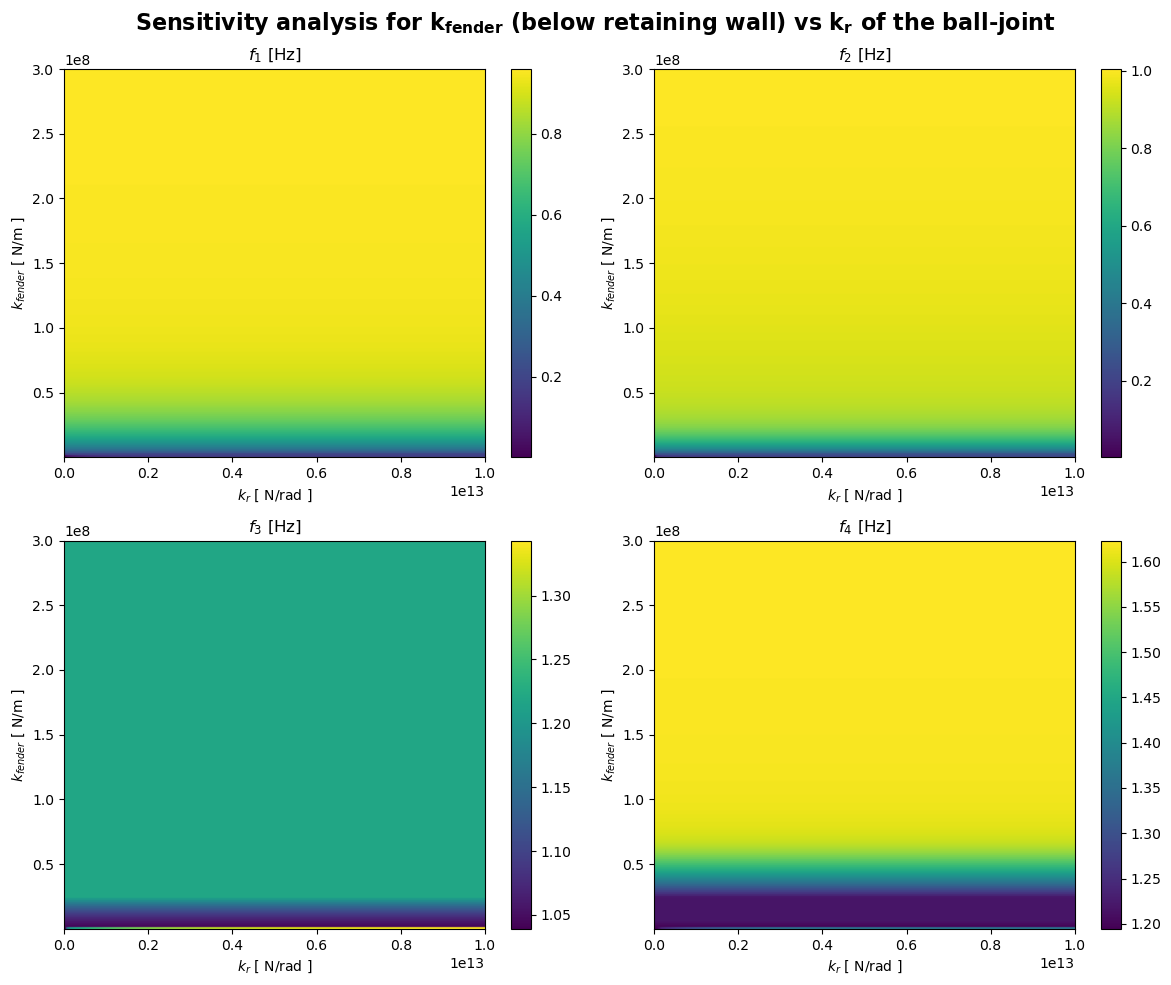

In [7]:
k_fender = np.arange(k_fender_min, k_fender_max, (k_fender_max - k_fender_min) / N)
kr = np.arange(kr_min, kr_max, (kr_max - kr_min) / N)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
titles = ['$f_1$ [Hz]', '$f_2$ [Hz]', '$f_3$ [Hz]', '$f_4$ [Hz]']

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        params_kfender_kr[:, :, i],
        extent=(kr_min, kr_max, k_fender_min, k_fender_max),
        origin='lower',
        aspect='auto'
    )
    
    ax.set_xlabel('$k_r$ [ N/rad ]')
    ax.set_ylabel('$k_{fender}$ [ N/m ]')
    ax.set_title(titles[i])
    
    fig.colorbar(im, ax=ax)

fig.suptitle(
    r'Sensitivity analysis for $\mathbf{k_{fender}}$ (below retaining wall) vs $\mathbf{k_r}$ of the ball-joint',
    fontsize=16,
    y=0.98,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('plots/model2_colorbar_kfender_kr.jpg', dpi=500)
plt.show()

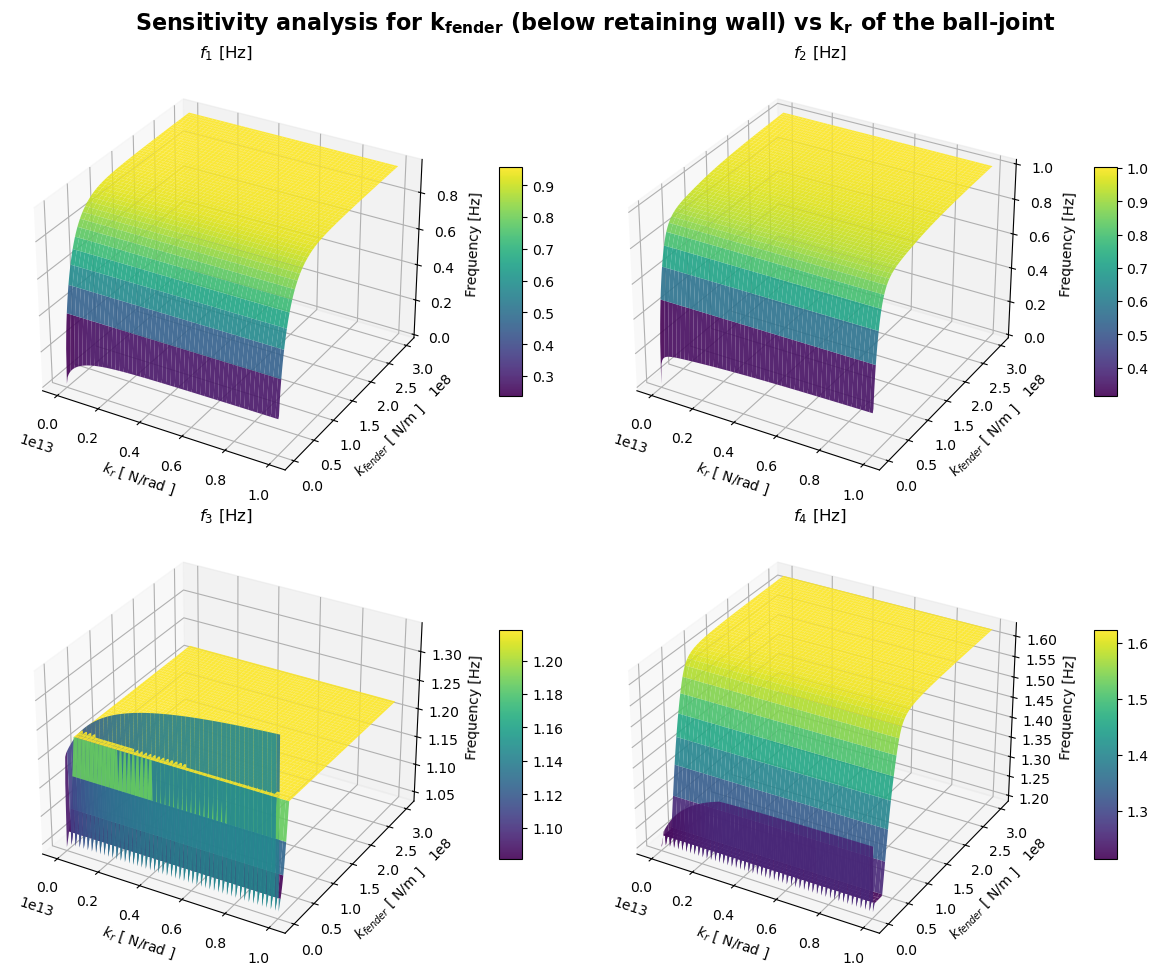

In [8]:

kr_grid, kf_grid = np.meshgrid(
    np.linspace(kr_min, kr_max, params_kfender_kr.shape[1]),
    np.linspace(k_fender_min, k_fender_max, params_kfender_kr.shape[0])
)

fig = plt.figure(figsize=(12, 10))
titles = ['$f_1$ [Hz]', '$f_2$ [Hz]', '$f_3$ [Hz]', '$f_4$ [Hz]']

for i in range(4):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    # Surface plot
    surf = ax.plot_surface(
        kr_grid, kf_grid, params_kfender_kr[:, :, i],
        cmap='viridis', alpha=0.9
    )
    
    ax.set_xlabel('$k_r$ [ N/rad ]', fontsize=10)
    ax.set_ylabel('$k_{fender}$ [ N/m ]', fontsize=10)
    ax.set_zlabel('Frequency [Hz]', fontsize=10)
    ax.set_title(titles[i])
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)

# Global bold title with bold math
fig.suptitle(
    r'Sensitivity analysis for $\mathbf{k_{fender}}$ (below retaining wall) vs $\mathbf{k_r}$ of the ball-joint',
    fontsize=16,
    y=0.98,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('plots/model2_3D_kfender_kr.jpg', dpi=500)
plt.show()

$k_r$ vs $k_y$

In [9]:
# Plots for kr vs Iy

kr_min = 0
kr_max = 10000000000000

Iy_min = 1500
Iy_max = 10000

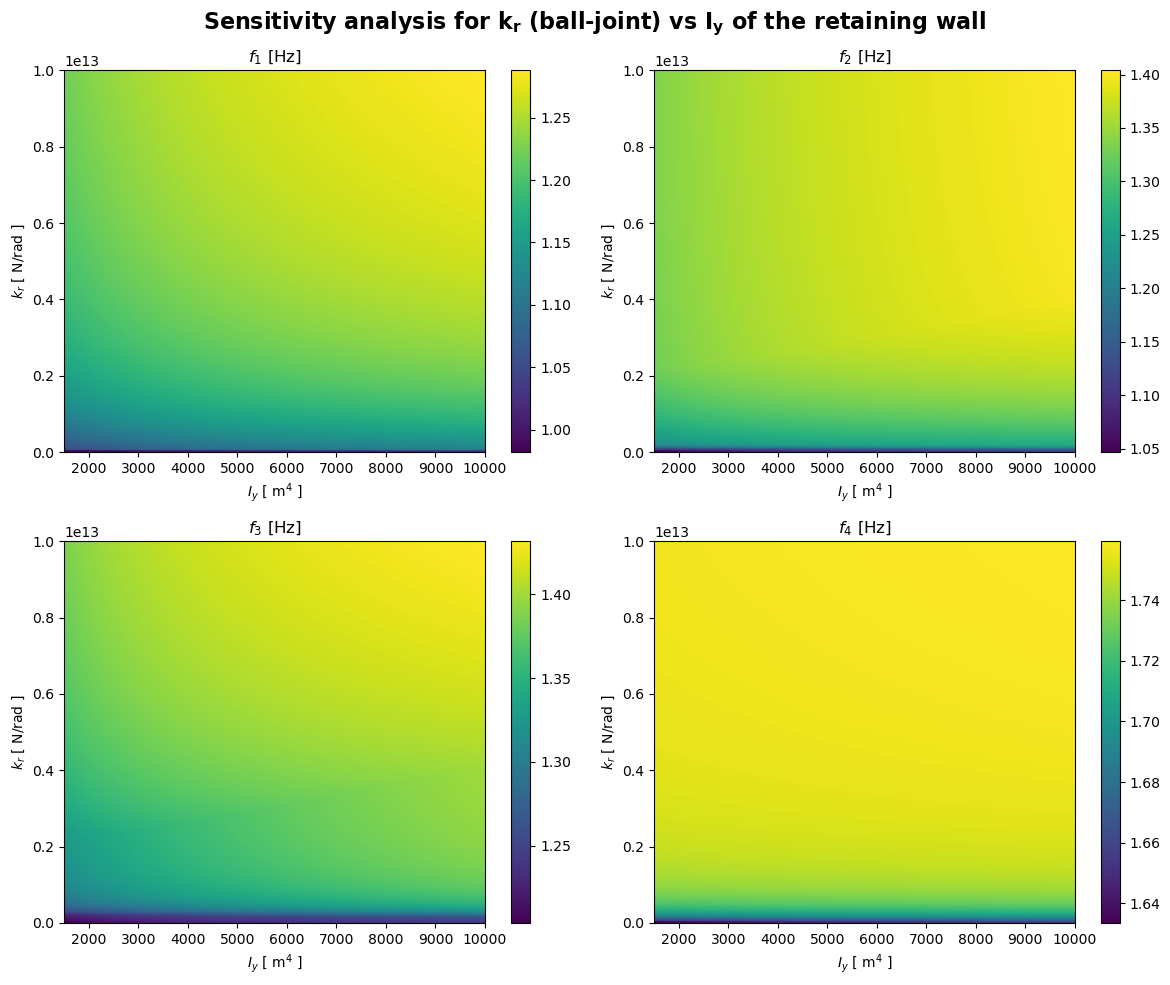

In [10]:
kr = np.arange(kr_min, kr_max, (kr_max - kr_min) / N)
Iy = np.arange(Iy_min, Iy_max, (Iy_max - Iy_min) / N)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
titles = ['$f_1$ [Hz]', '$f_2$ [Hz]', '$f_3$ [Hz]', '$f_4$ [Hz]']

for i, ax in enumerate(axes.flat):
    im = ax.imshow(
        params_kr_Iy[:, :, i],
        extent=(Iy_min, Iy_max, kr_min, kr_max),
        origin='lower',
        aspect='auto'
    )
    
    ax.set_xlabel('$I_y$ [ m$^4$ ]')
    ax.set_ylabel('$k_r$ [ N/rad ]')
    ax.set_title(titles[i])
    
    fig.colorbar(im, ax=ax)

fig.suptitle(
    r'Sensitivity analysis for $\mathbf{k_r}$ (ball-joint) vs $\mathbf{I_y}$ of the retaining wall',
    fontsize=16,
    y=0.98,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('plots/model2_colorbar_kr_Iy.jpg', dpi=500)
plt.show()

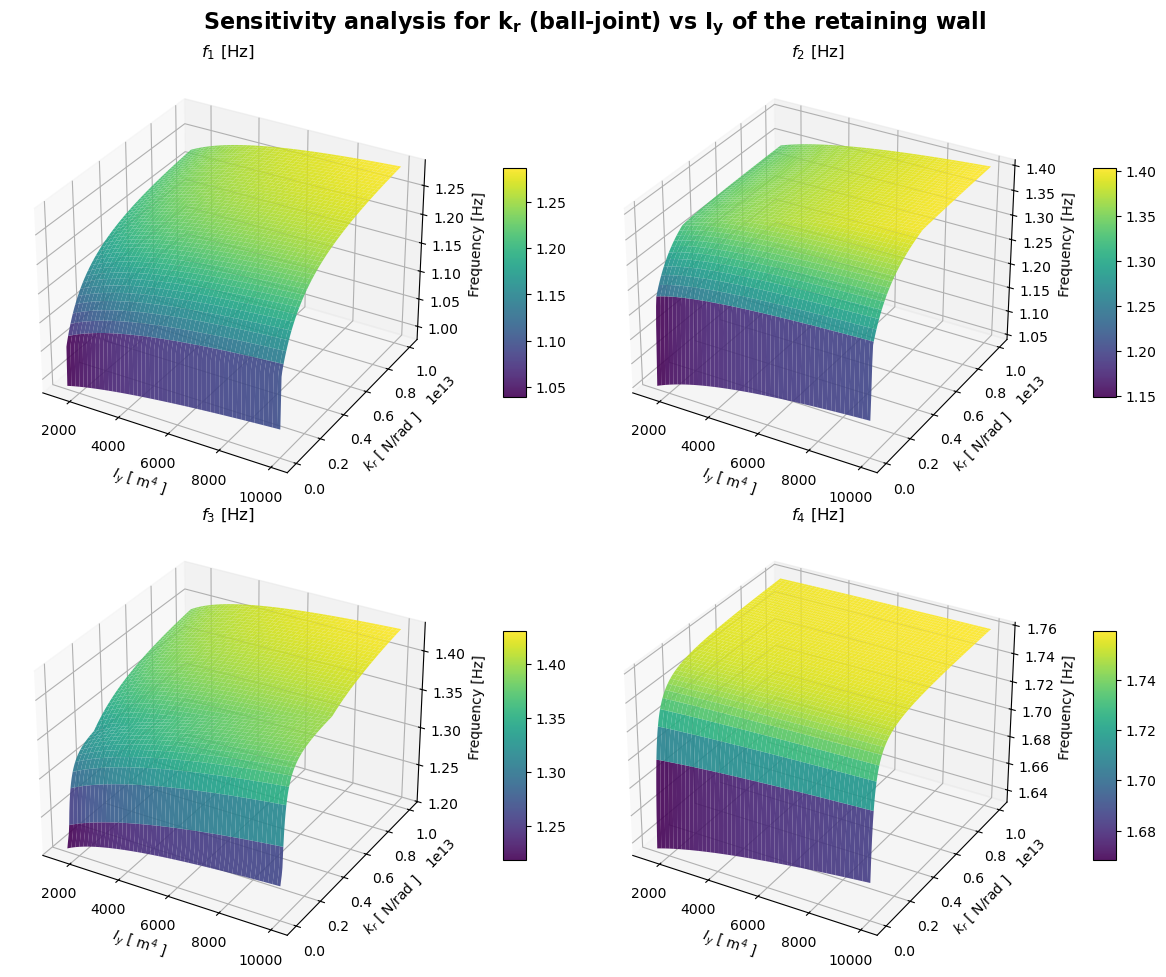

In [11]:
Iy_grid, kr_grid = np.meshgrid(
    np.linspace(Iy_min, Iy_max, params_kr_Iy.shape[1]),
    np.linspace(kr_min, kr_max, params_kr_Iy.shape[0])
)

fig = plt.figure(figsize=(12, 10))
titles = ['$f_1$ [Hz]', '$f_2$ [Hz]', '$f_3$ [Hz]', '$f_4$ [Hz]']

for i in range(4):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    # Surface plot
    surf = ax.plot_surface(
        Iy_grid, kr_grid, params_kr_Iy[:, :, i],
        cmap='viridis', alpha=0.9
    )
    
    ax.set_xlabel('$I_y$ [ m$^4$ ]', fontsize=10)
    ax.set_ylabel('$k_r$ [ N/rad ]', fontsize=10)
    ax.set_zlabel('Frequency [Hz]', fontsize=10)
    ax.set_title(titles[i])
    
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)

# Global bold title with bold math
fig.suptitle(
    r'Sensitivity analysis for $\mathbf{k_r}$ (ball-joint) vs $\mathbf{I_y}$ of the retaining wall',
    fontsize=16,
    y=0.98,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('plots/model2_3D_kr_Iy.jpg', dpi=500)
plt.show()